# VAE Training — H1N1 & H3N2

Trains a Conv1d VAE on **both** influenza subtypes with identical hyperparameters
for a fair architecture comparison. Saves checkpoints and runs full latent-space
inference (UMAP, t-SNE, clustering) for each subtype.

In [3]:
# if we're on Colab, clone the repo so we have all source files
import os
if not os.path.exists('models'):
    !git clone https://github.com/sidms24/AML.git
    os.chdir('AML')
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 11.6 MB/s eta 0:00:00


## Shared Hyperparameters

Both H1N1 and H3N2 models use **identical** settings for fair comparison.

In [4]:
from tqdm import tqdm
# force plain text progress bars before importing HF libraries
import tqdm.auto, tqdm.std
tqdm.auto.tqdm = tqdm.std.tqdm
import torch
from models.vae import VAE
from utils.dataloader import load_data
from utils.encoders import dna_one_hot
from utils.loss import VAE_Loss
from utils.train import VAE_train
from utils.inference import extract_latents, latent_analysis
from utils.plot_funcs import plot_training_curves
import matplotlib.pyplot as plt  # for the side-by-side comparison figure
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# we keep these identical across all three architectures for a fair comparison
best_config = {'latent_dim': 64, 'beta': 0.010239273411172712, 'hidden_dim': 128}
HIDDEN_DIM = best_config['hidden_dim']
LATENT_DIM = best_config['latent_dim']
BATCH_SIZE = 512
EPOCHS = 200
LR  = 3e-5
BETA = best_config['beta']
ANNEAL_EPOCHS = 10  # KL weight ramps linearly from 0 to BETA over this many epochs
PATIENCE = 10   # early stopping kicks in only after annealing finishes

Device: cuda


In [5]:
# reproducibility — pin all sources of randomness so training is deterministic
import numpy as np
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True

# H1N1

In [6]:
h1n1_data = load_data(subtype='H1N1_global', encoder=dna_one_hot, batch_size=BATCH_SIZE)
h1n1_train, h1n1_test = h1n1_data()

# we grab one batch to auto-detect input shape — the VAE needs these at init
sample_x, _ = next(iter(h1n1_train))
INPUT_DIM = sample_x.shape[1]   # 5 channels (one-hot: A, C, G, T, gap)
SEQ_LENGTH = sample_x.shape[2]
print(f'H1N1 — input_dim={INPUT_DIM}, seq_length={SEQ_LENGTH}, batches={len(h1n1_train)}')

Map (num_proc=4): 100%|██████████| 6245/6245 [00:01<00:00, 4152.05 examples/s]


H1N1 — input_dim=5, seq_length=1759, batches=49


In [7]:
vae_h1n1 = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM, SEQ_LENGTH).to(device)
criterion_h1n1 = VAE_Loss(beta=BETA)
optimiser_h1n1 = torch.optim.Adam(vae_h1n1.parameters(), lr=LR)

# VAE_train handles KL annealing and early stopping internally
vae_h1n1, history_h1n1 = VAE_train(
    vae_h1n1, h1n1_train, h1n1_test,
    criterion_h1n1, optimiser_h1n1, device,
    epochs=EPOCHS, patience=PATIENCE, anneal_epochs=ANNEAL_EPOCHS
)

Training:   5%|▌         | 10/200 [00:58<08:25,  2.66s/epoch, avg loss=44.7058]

  Checkpoint saved at epoch 10 -> checkpoint.pt


Training:  10%|█         | 20/200 [01:19<06:51,  2.29s/epoch, avg loss=26.4595]

  Checkpoint saved at epoch 20 -> checkpoint.pt


Training:  15%|█▌        | 30/200 [01:41<06:26,  2.27s/epoch, avg loss=18.9939]

...

  Checkpoint saved at epoch 140 -> checkpoint.pt


Training:  75%|███████▌  | 150/200 [06:04<01:56,  2.33s/epoch, avg loss=3.2802]

  Checkpoint saved at epoch 150 -> checkpoint.pt


Training:  80%|███████▉  | 159/200 [06:25<01:39,  2.42s/epoch, avg loss=2.9750]


Early stopping triggered at Epoch 160.


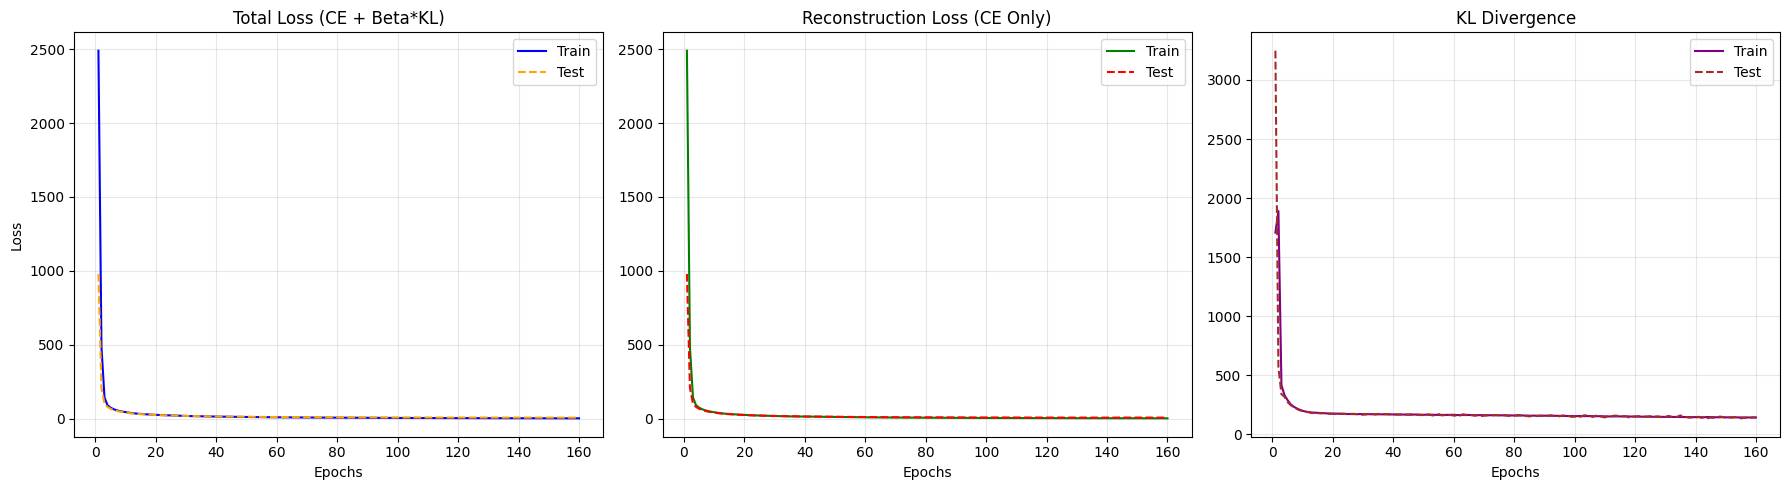

In [8]:
plot_training_curves(history_h1n1)  # recon, KL, and total loss

Computing UMAP (n_neighbors=15, min_dist=0.1)...
Optimal k (2 to 10)...
Automatically selected k=9
Silhouette — KMeans: 0.4604, Season: 0.0397


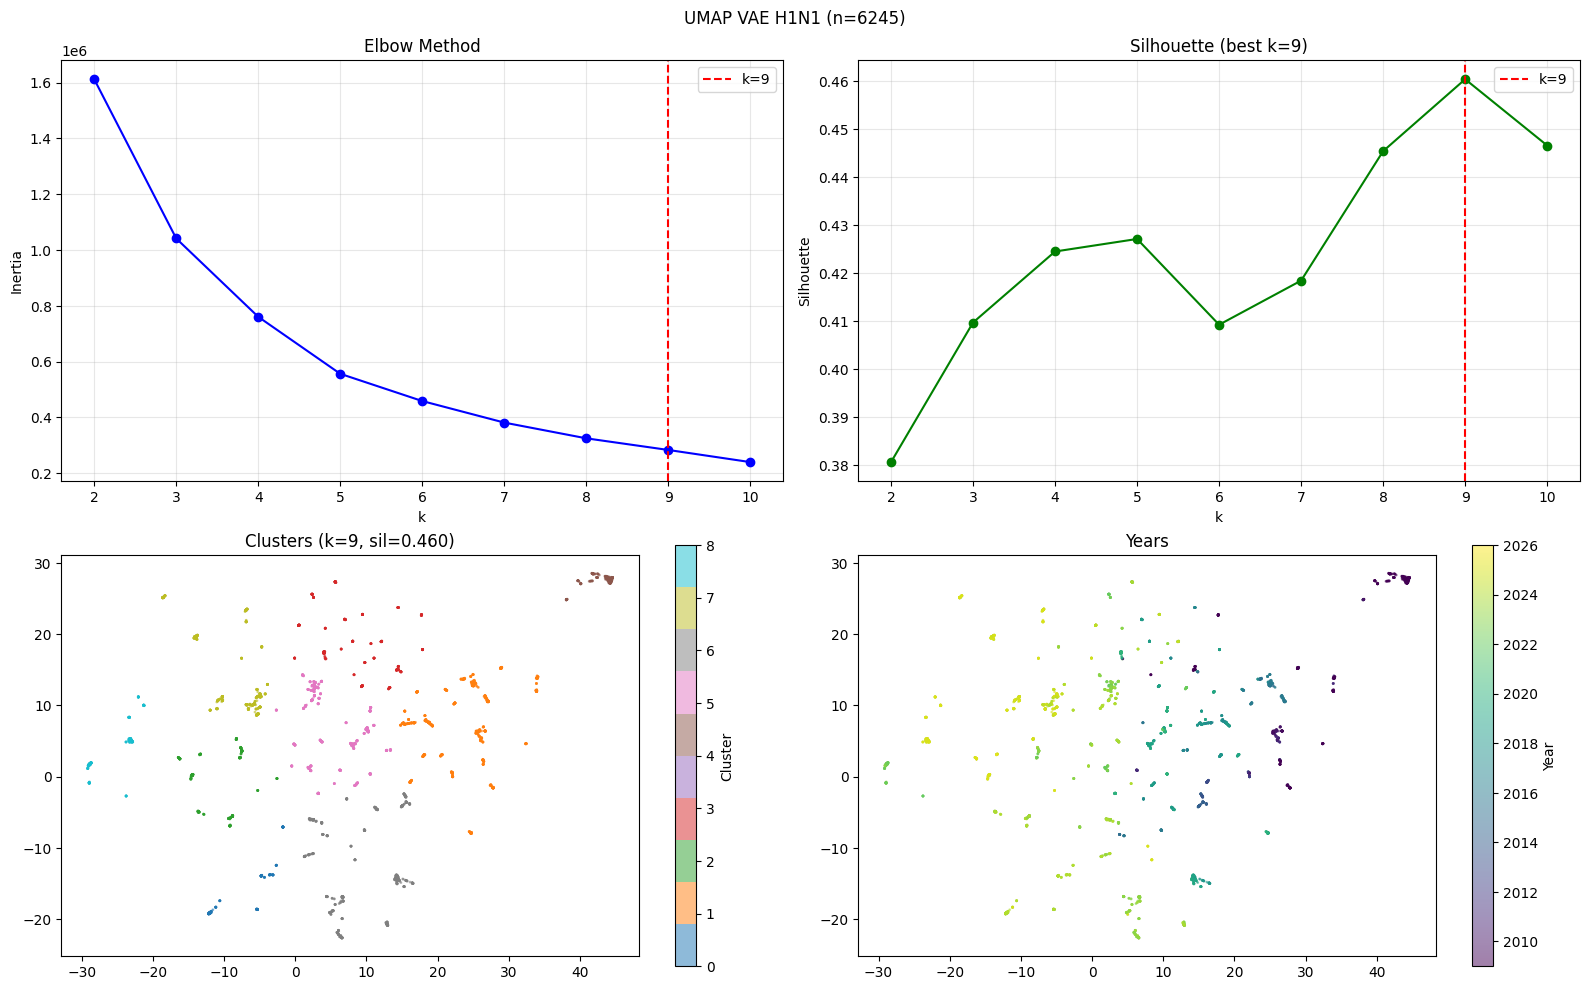

In [9]:
# we run on test set only — latents from training data would overfit the embedding
analyser_h1n1 = latent_analysis(vae_h1n1, h1n1_test, device=device)
emb_h1n1 = analyser_h1n1.analyse(method='umap', n_clusters='auto', max_k=10,
                                  title='VAE H1N1')

Using cached UMAP embeddings.
Computing t-SNE (perplexity=30)...


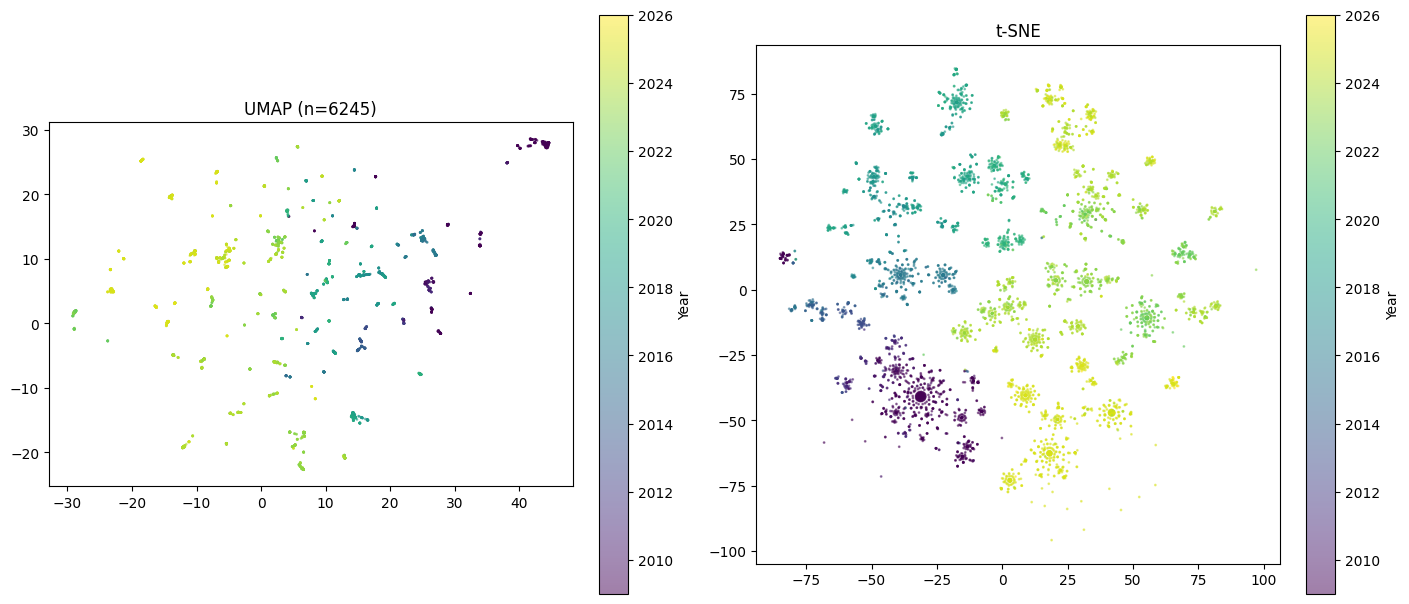

Balanced to 34 sequences × 17 seasons = 578 total


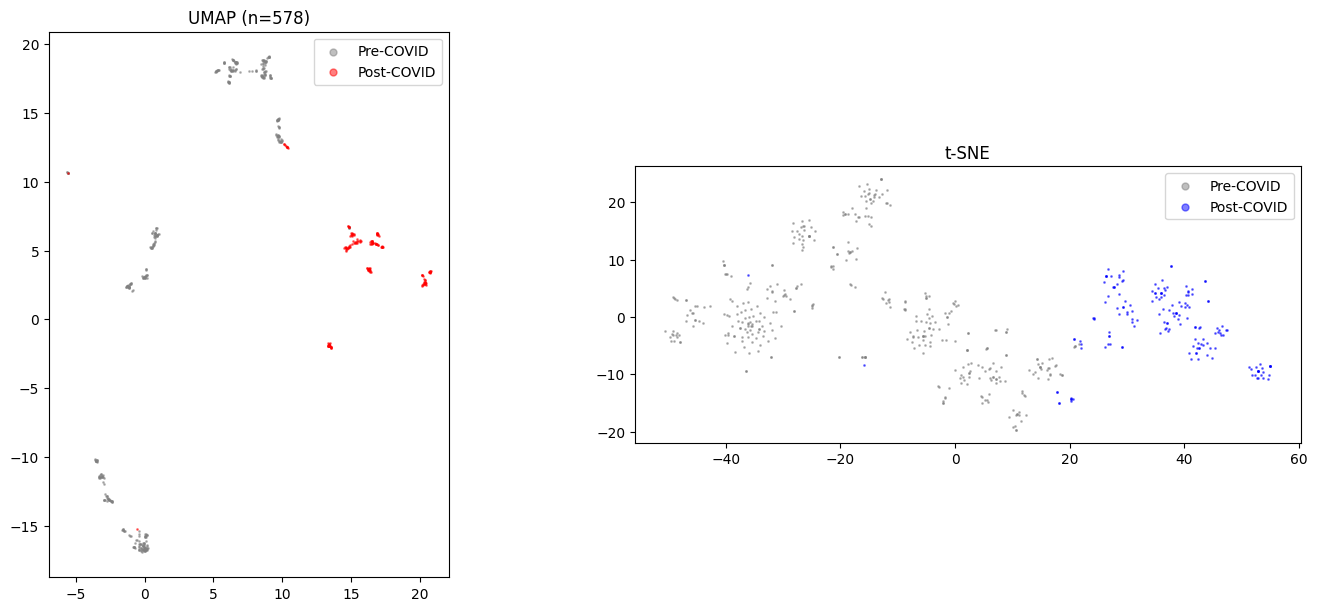

In [10]:
# year colouring helps us see if the latent space captures temporal drift
analyser_h1n1.plot_umap_tsne(color_by='year')
# 2020 split — we want to see if post-covid sequences land in a distinct region
analyser_h1n1.plot_pre_post_covid(covid_year=2020)

In [11]:
# we save config alongside weights so we can reconstruct the model without guessing dims
torch.save({
    'model_state_dict': vae_h1n1.state_dict(),
    'config': {'input_dim': INPUT_DIM, 'hidden_dim': HIDDEN_DIM,
               'latent_dim': LATENT_DIM, 'seq_length': SEQ_LENGTH},
    'history': history_h1n1,
}, 'vae_h1n1_weights.pt')
print('Saved vae_h1n1_weights.pt')

Saved vae_h1n1_weights.pt


# H3N2

In [12]:
# same pipeline as H1N1 — H3N2 seqs may differ in length
h3n2_data = load_data(subtype='H3N2_global', encoder=dna_one_hot, batch_size=BATCH_SIZE)
h3n2_train, h3n2_test = h3n2_data()

sample_x2, _ = next(iter(h3n2_train))
INPUT_DIM_H3 = sample_x2.shape[1]
SEQ_LENGTH_H3 = sample_x2.shape[2]
print(f'H3N2 — input_dim={INPUT_DIM_H3}, seq_length={SEQ_LENGTH_H3}, batches={len(h3n2_train)}')

Map (num_proc=4): 100%|██████████| 9332/9332 [00:03<00:00, 2961.33 examples/s]


H3N2 — input_dim=5, seq_length=1854, batches=73


In [ ]:
# fresh model — using the H3-specific constants
vae_h3n2 = VAE(INPUT_DIM_H3, HIDDEN_DIM, LATENT_DIM, SEQ_LENGTH_H3).to(device)
criterion_h3n2 = VAE_Loss(beta=BETA)
optimiser_h3n2 = torch.optim.Adam(vae_h3n2.parameters(), lr=LR)

print(f"Starting H3N2 training on {device}...")

vae_h3n2, history_h3n2 = VAE_train(
    vae_h3n2, h3n2_train, h3n2_test,
    criterion_h3n2, optimiser_h3n2, device,
    epochs=EPOCHS, patience=PATIENCE, anneal_epochs=ANNEAL_EPOCHS
)

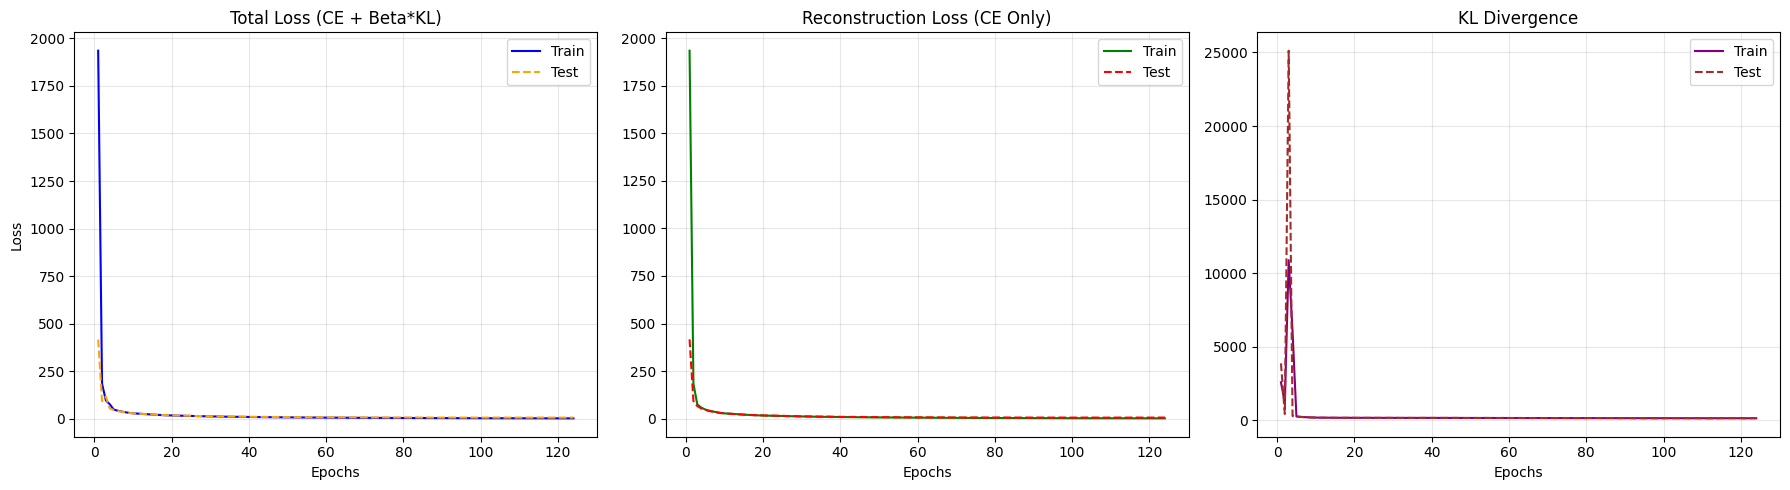

In [14]:
plot_training_curves(history_h3n2)

Computing UMAP (n_neighbors=15, min_dist=0.1)...
Optimal k (2 to 10)...
Automatically selected k=10
Silhouette — KMeans: 0.4449, Season: 0.0837


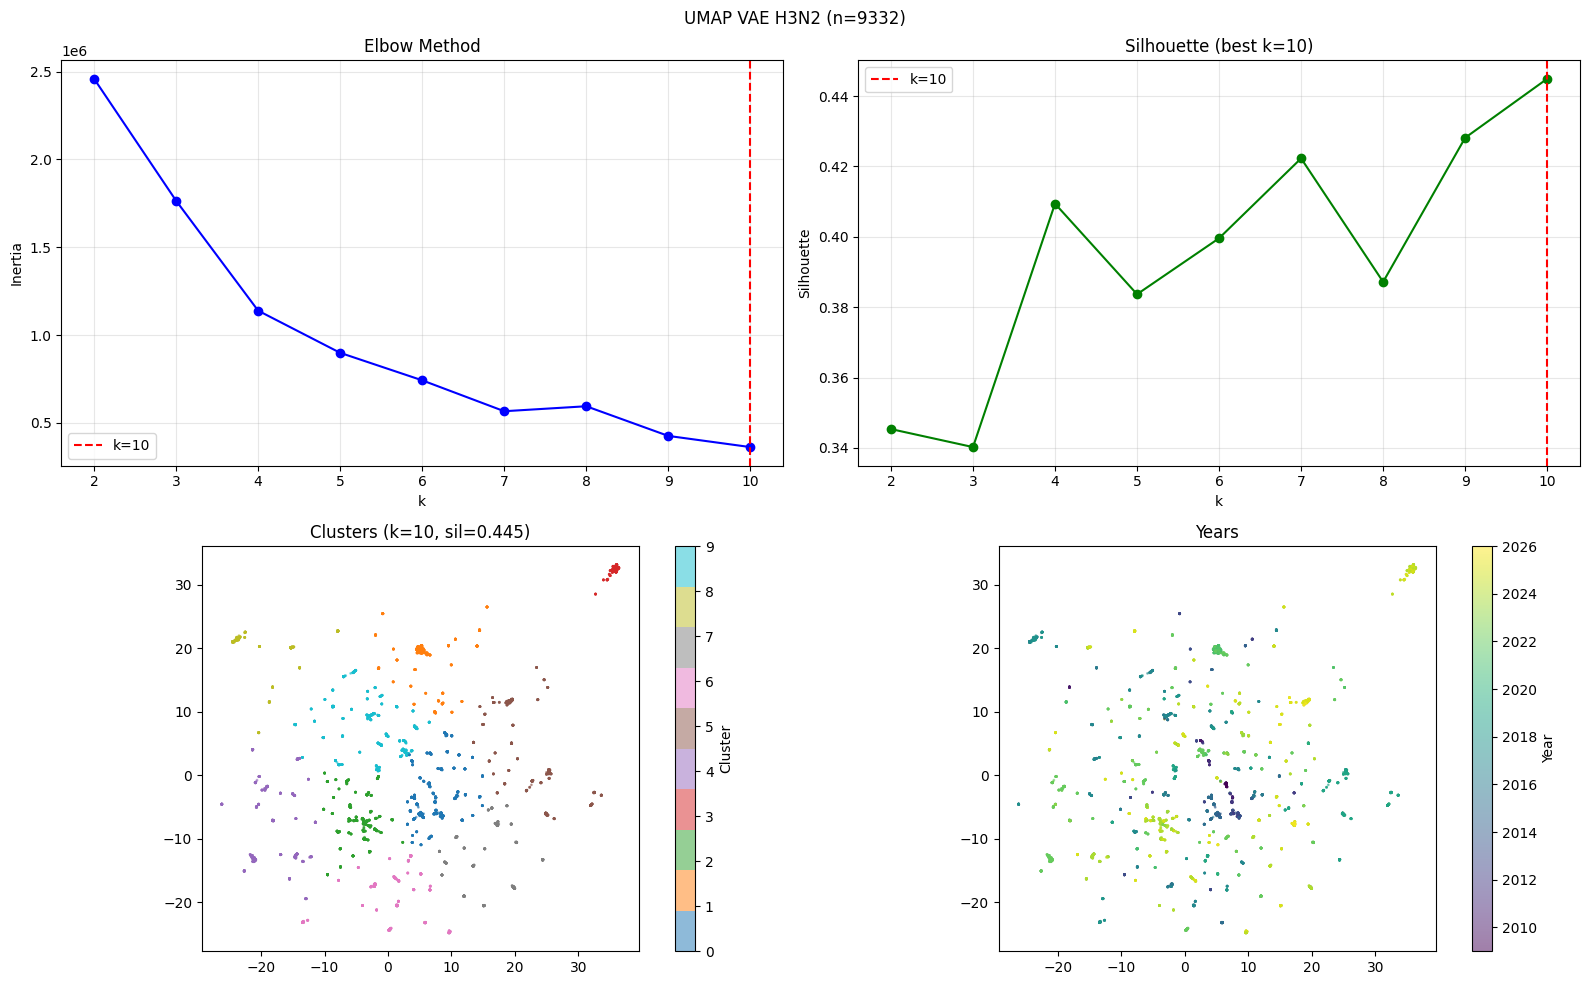

In [15]:
analyser_h3n2 = latent_analysis(vae_h3n2, h3n2_test, device=device)
emb_h3n2 = analyser_h3n2.analyse(method='umap', n_clusters='auto', max_k=10,
                                  title='VAE H3N2')

Using cached UMAP embeddings.
Computing t-SNE (perplexity=30)...


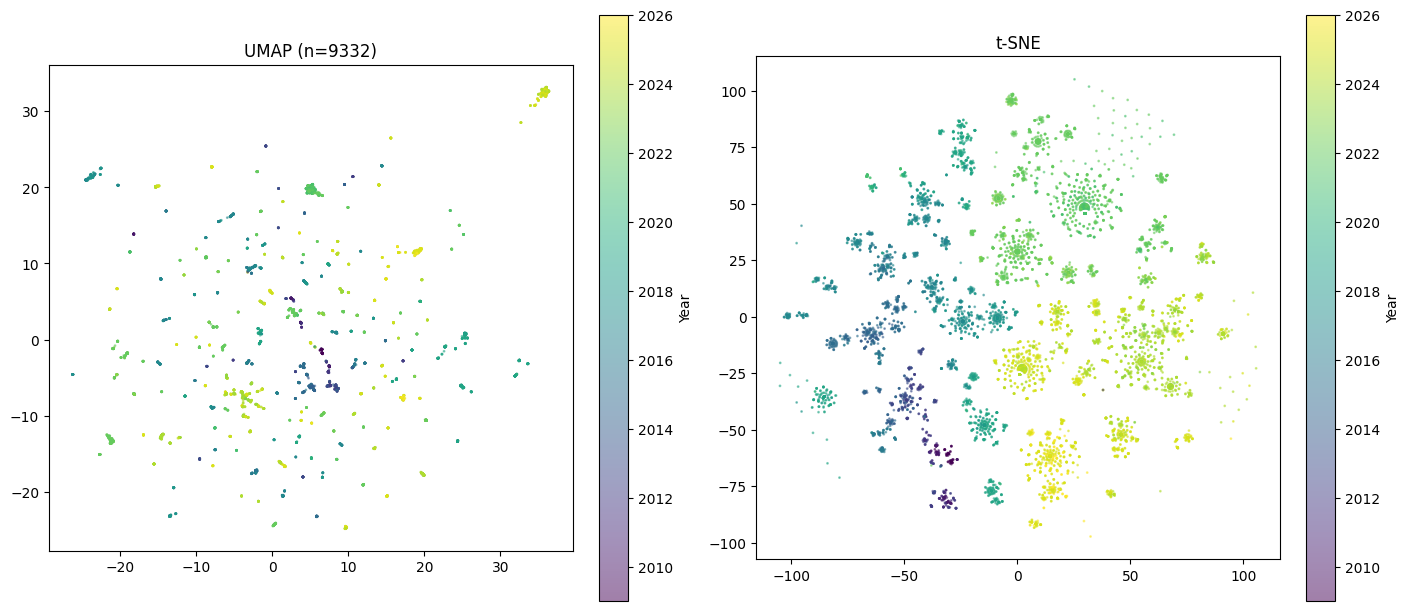

Balanced to 44 sequences × 17 seasons = 748 total


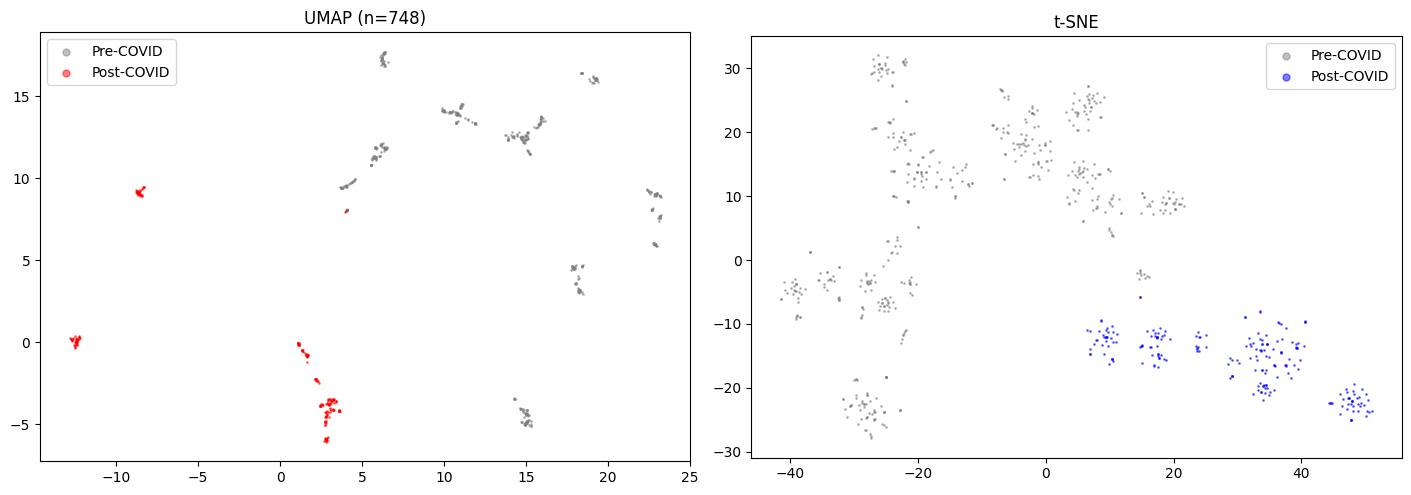

In [16]:
analyser_h3n2.plot_umap_tsne(color_by='year')
analyser_h3n2.plot_pre_post_covid(covid_year=2020)

In [17]:
torch.save({
    'model_state_dict': vae_h3n2.state_dict(),
    'config': {'input_dim': INPUT_DIM_H3, 'hidden_dim': HIDDEN_DIM,
               'latent_dim': LATENT_DIM, 'seq_length': SEQ_LENGTH_H3},
    'history': history_h3n2,
}, 'vae_h3n2_weights.pt')
print('Saved vae_h3n2_weights.pt')

Saved vae_h3n2_weights.pt


# Side-by-Side Comparison

Using cached UMAP embeddings.
Using cached UMAP embeddings.


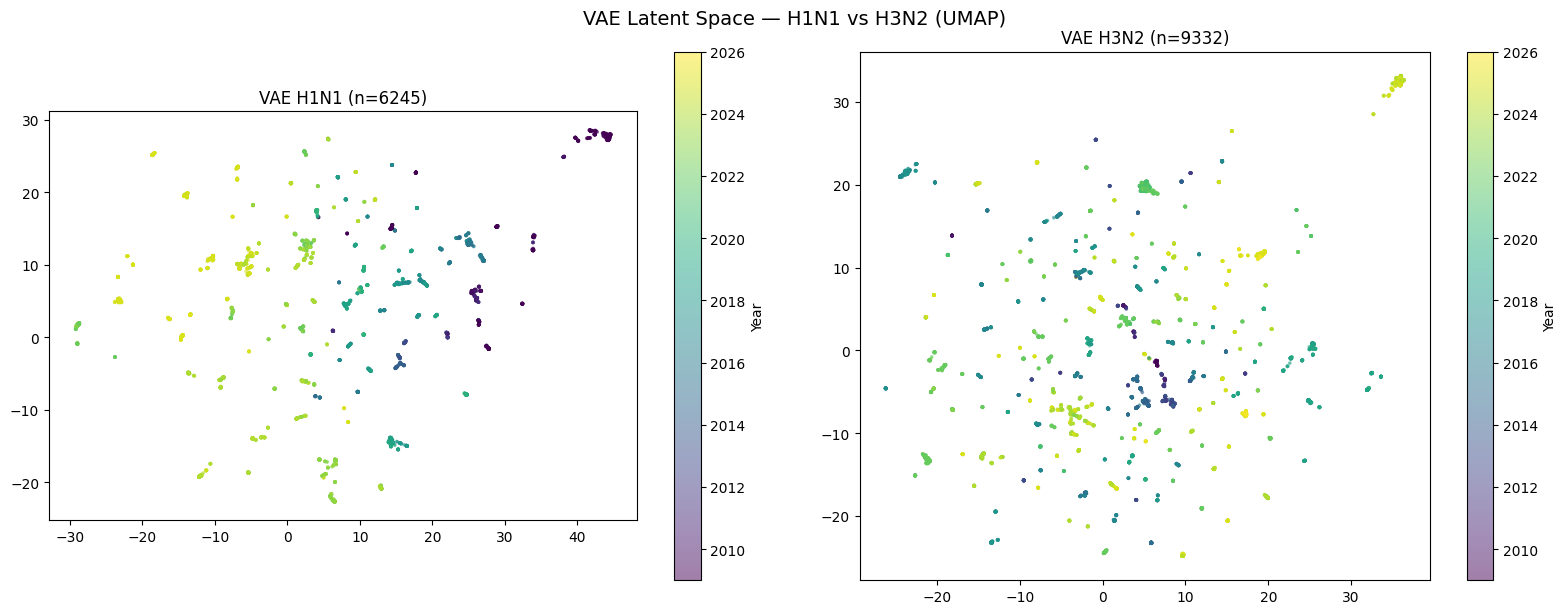

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# H1N1 — we reuse the cached UMAP embedding so this is instant
umap_h1 = analyser_h1n1.umap_embed()
sc1 = axes[0].scatter(umap_h1[:, 0], umap_h1[:, 1], c=analyser_h1n1.years,
                      cmap='viridis', alpha=0.5, s=3, rasterized=True)
plt.colorbar(sc1, ax=axes[0], label='Year')
axes[0].set_title(f'VAE H1N1 (n={len(umap_h1)})')
axes[0].set_aspect('equal', adjustable='box')

# H3N2
umap_h3 = analyser_h3n2.umap_embed()
sc2 = axes[1].scatter(umap_h3[:, 0], umap_h3[:, 1], c=analyser_h3n2.years,
                      cmap='viridis', alpha=0.5, s=3, rasterized=True)
plt.colorbar(sc2, ax=axes[1], label='Year')
axes[1].set_title(f'VAE H3N2 (n={len(umap_h3)})')
axes[1].set_aspect('equal', adjustable='box')

plt.suptitle('VAE Latent Space — H1N1 vs H3N2 (UMAP)', fontsize=14)
plt.tight_layout()
plt.show()

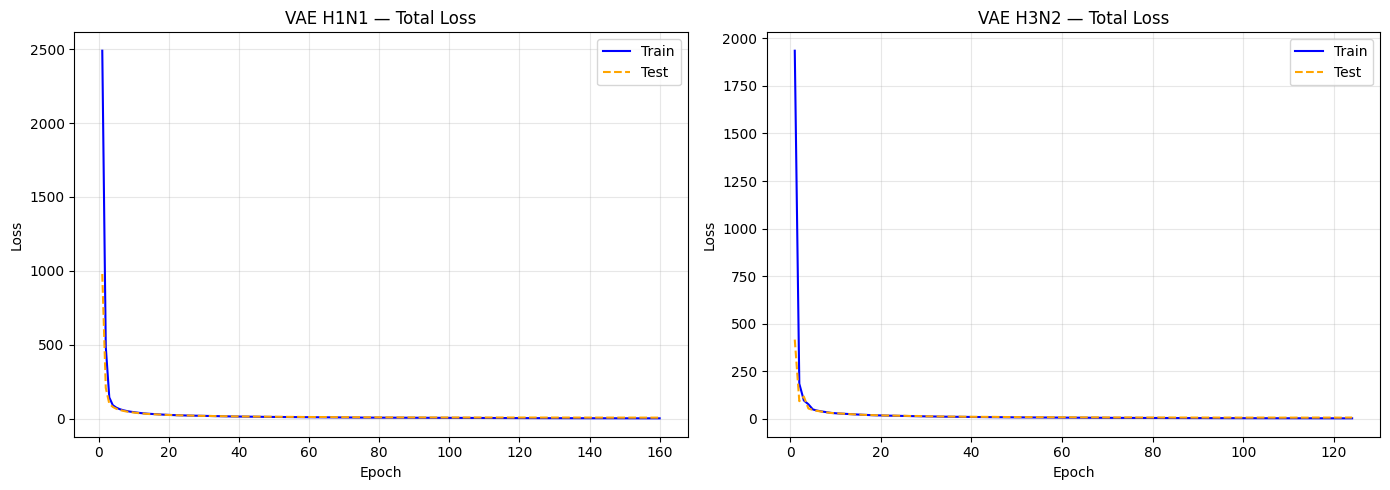

H1N1 final test loss: 7.79
H3N2 final test loss: 6.95


In [19]:
# sanity check — if one subtype converges much faster, we may need to revisit lr or patience
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, name in [(axes[0], history_h1n1, 'H1N1'), (axes[1], history_h3n2, 'H3N2')]:
    ep = range(1, len(hist['train_tloss']) + 1)
    ax.plot(ep, hist['train_tloss'], label='Train', color='blue')
    ax.plot(ep, hist['test_tloss'], label='Test', color='orange', linestyle='--')
    ax.set_title(f'VAE {name} — Total Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'H1N1 final test loss: {history_h1n1["test_tloss"][-1]:.2f}')
print(f'H3N2 final test loss: {history_h3n2["test_tloss"][-1]:.2f}')

In [ ]:
from datasets import Dataset, DatasetDict
from huggingface_hub import login, upload_file
from google.colab import userdata

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
hf_token = userdata.get('HF_TOKEN')

models = ['vae_h3n2_weights.pt', 'vae_h1n1_weights.pt']
for model in models:
  upload_file(
      path_or_fileobj=model,
      repo_id='sidms/AML',
      path_in_repo= f'weights/{model}',
      repo_type= 'dataset',
      token=hf_token
  )